In [1]:
import edn_popdyn.paths
from edn_popdyn.paths import STATS_CSV_DIR
from edn_popdyn import colors as pal

# 4.2 — Reaction time vs cue validity

Compare reaction times across valid, invalid, and no-cue conditions with pseudoreplication-aware (subject-level and mixed-model) statistics.

## 0) Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy.stats
import seaborn as sns
import statsmodels.formula.api as smf
import sys
import warnings

from behav import loading, plotting, utils
from cdcp.behavior.data import bin_data, cue_direction, prepare_behavior_data
from cdcp.experiment_info import subjects
from edn_popdyn.paths import MAGPI_RAW as DATA_PATH_MAGPI
from matplotlib import rcParams
from scipy import stats
from scipy.interpolate import make_interp_spline
from scipy.stats import friedmanchisquare, kruskal, mannwhitneyu, rankdata, ttest_rel, wilcoxon
from tqdm.autonotebook import tqdm

/tmp/ipykernel_1313247/352782511.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
pd.set_option('display.max_columns', 500)

In [4]:
rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

In [5]:
valid_color   = pal.valid
invalid_color = pal.invalid_accent
NC_color      = pal.nc_gray

## 2) load data

In [6]:
def prepare_behavior_data(data, num_bins=16, num_prev=np.inf):

    data = data[data["response"] != "none"]

    if num_prev != np.inf:
        data = data[-num_prev:]

    data["response_bool"] = 0
    data.loc[data["response"] == "L", "response_bool"] = 1

    data['interpolation_point'] = 127 - data['interpolation_point']
    data['response_bool'] = 1 - data['response_bool']

    data["interpolation"] = [
        ls + rs for ls, rs in zip(data.left_stim.values, data.right_stim.values)
    ]

    data["pos_bin"], bins = bin_data(
        data["interpolation_point"].values.astype("float32"), num_bins
    )
    data["cue_direction"] = data.cue_id.apply(cue_direction)
    return data, bins

In [7]:
from edn_popdyn.behavior_rt_io import (
    load_behavior_table, save_behavior_table, table_path,
)
from edn_popdyn.paths import BEHAVIOR_RT_DIR

# Set True to ignore the saved table and rebuild from Magpi (cluster only).
FORCE_REBUILD = False

_existing, _ = table_path(BEHAVIOR_RT_DIR)

if _existing is not None and not FORCE_REBUILD:
    behav_data_all = load_behavior_table(BEHAVIOR_RT_DIR)

else:
    # ---- build from raw Magpi (cluster only), then save for reuse ----------
    total_trials = 0
    nex = 100000
    behav_data_all = []

    for subject in tqdm(subjects):
        print(f"\nProcessing subject: {subject}")

        try:
            behav_data_subject = loading.load_data_pandas([subject], DATA_PATH_MAGPI)

            if not isinstance(behav_data_subject, dict):
                print(f"Warning: Expected dictionary but got "
                      f"{type(behav_data_subject)} for subject {subject}")
                continue

            if subject not in behav_data_subject:
                print(f"Warning: Subject {subject} not found in loaded data")
                continue

            behav_data_subject = behav_data_subject[subject]

            print(f"Subject {subject} data type: {type(behav_data_subject)}")
            print(f"Number of trials before preprocessing: {len(behav_data_subject)}")

            behav_data_subject, bins = prepare_behavior_data(behav_data_subject,
                                                             num_bins=32)

            if behav_data_subject.empty:
                print(f"Warning: No valid data for subject {subject} after preprocessing")
                continue

            total_trials += len(behav_data_subject)

            behav_data_subject = behav_data_subject[behav_data_subject.rt.notnull()]

            print(f"Trials remaining after NaN removal: {len(behav_data_subject)}")

            if len(behav_data_subject) < nex:
                behav_data_subject = behav_data_subject[20000:]

            behav_data_subject = behav_data_subject[-nex:]
            behav_data_subject['subject'] = subject

            behav_data_all.append(behav_data_subject)

        except Exception as e:
            print(f"Error processing subject {subject}: {e}")
            continue

    if behav_data_all:
        behav_data_all = pd.concat(behav_data_all)
        behav_data_all = behav_data_all[behav_data_all.rt >= 0]
        print(f"\nFinal dataset size: {behav_data_all.shape}")
        save_behavior_table(behav_data_all, BEHAVIOR_RT_DIR)
    else:
        raise RuntimeError("No valid data collected from Magpi.")

# --- cheap sanity check: catches a truncated or wrong-version table ----------
_need = {"subject", "rt", "response", "class_", "cue_class", "interpolation_point"}
_missing = _need - set(behav_data_all.columns)
assert not _missing, f"behavior table is missing columns: {sorted(_missing)}"
print(f"{len(behav_data_all):,} trials, {behav_data_all.subject.nunique()} subjects, "
      f"rt {behav_data_all.rt.min():.3f}-{behav_data_all.rt.max():.3f}")

loaded 1,879,805 trials from 19 subjects <- /mnt/cube/jugorman/EDNpopdyn/data/behavior_rt/fig4_behavior_rt.csv.gz
1,879,805 trials, 19 subjects, rt 0.000-4.995


## 3) norm mean from reaction time to account for side bias

In [8]:
def z_score(x):
    return (x - np.nanmean(x)) / np.nanstd(x)

In [9]:
behav_data_all["normed_rt"] = np.nan
for subject in tqdm(behav_data_all.subject.unique()):

    behav_data_all.loc[
        (behav_data_all.subject.values == subject) & (behav_data_all.response.values == "L"),
        "normed_rt_decision",
    ] = z_score(
        behav_data_all.loc[
            (behav_data_all.subject.values == subject) & (behav_data_all.response.values == "L"),
            "rt",
        ]
    )

    behav_data_all.loc[
        (behav_data_all.subject.values == subject) & (behav_data_all.response.values == "R"),
        "normed_rt_decision",
    ] = z_score(
        behav_data_all.loc[
            (behav_data_all.subject.values == subject) & (behav_data_all.response.values == "R"),
            "rt",
        ]
    )

    behav_data_all.loc[
        (behav_data_all.subject.values == subject) & (behav_data_all.class_.values == "L"),
        "normed_rt_class",
    ] = z_score(
        behav_data_all.loc[
            (behav_data_all.subject.values == subject) & (behav_data_all.class_.values == "L"),
            "rt",
        ]
    )

    behav_data_all.loc[
        (behav_data_all.subject.values == subject) & (behav_data_all.class_.values == "R"),
        "normed_rt_class",
    ] = z_score(
        behav_data_all.loc[
            (behav_data_all.subject.values == subject) & (behav_data_all.class_.values == "R"),
            "rt",
        ]
    )

  0%|          | 0/19 [00:00<?, ?it/s]

In [10]:
behav_data_all['validity'] = np.where(
    (behav_data_all['cue_class'] == 'CR') & (behav_data_all['interpolation_point'].between(0, 63)),
    'invalid',
    np.where(
        (behav_data_all['cue_class'] == 'CR'),
        'valid',
        np.where(
            (behav_data_all['cue_class'] == 'CL') & (behav_data_all['interpolation_point'].between(0, 63)),
            'valid',
            np.where(
                (behav_data_all['cue_class'] == 'CL') & (behav_data_all['interpolation_point'].between(64, 127)),
                'invalid',
                pd.NA
            )
        )
    )
)

print(behav_data_all[['cue_class', 'interpolation_point', 'validity']].head())

  cue_class interpolation_point validity
0        CL                20.0    valid
1        NC                17.0     <NA>
2        CL                40.0    valid
3        NC                14.0     <NA>
4        CL                26.0    valid


In [11]:
present = set(behav_data_all['subject'].unique())
for b in ["B1426", "B1593"]:
    print(b, "in behav_data_all:", b in present)
    if b in present:
        sub = behav_data_all[behav_data_all.subject == b]
        print("   n rows:", len(sub),
              "| rt range:", sub['rt'].min(), "-", sub['rt'].max(),
              "| validity counts:", sub['validity'].value_counts(dropna=False).to_dict())

B1426 in behav_data_all: True
   n rows: 99999 | rt range: 0.00023 - 4.991369 | validity counts: {'valid': 64292, <NA>: 20125, 'invalid': 15582}
B1593 in behav_data_all: True
   n rows: 100000 | rt range: 0.000208 - 4.974943 | validity counts: {'valid': 62234, <NA>: 20594, 'invalid': 17172}


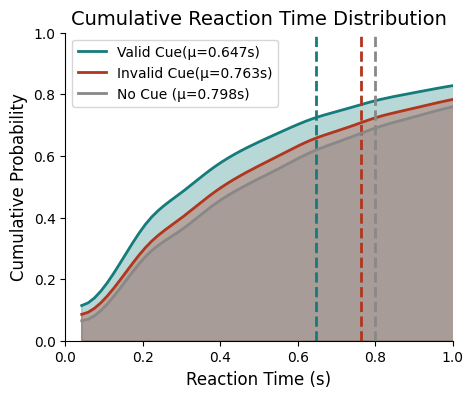

Figure saved: /mnt/cube/jugorman/EDNpopdyn/for_github/reaction_time_cdf_linear.svg


In [12]:
plot_data = behav_data_all.copy()
plot_data["validity"] = plot_data["validity"].fillna("NC")
plot_data = plot_data[plot_data["rt"] >= 0]
if "SUBJECT_SET" in dir() and SUBJECT_SET is not None:
    plot_data = plot_data[plot_data["subject"].isin(SUBJECT_SET)]
if "NC_color" not in dir():
    NC_color = "0.5"

mean_rt = plot_data.groupby("validity")["rt"].mean().to_dict()

bins = np.linspace(0, np.ceil(plot_data["rt"].max()), 60)

fig, ax = plt.subplots(figsize=(5, 4))

def plot_smooth_cdf(data, color, label):
    if len(data) == 0:
        return

    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    cumulative = np.cumsum(counts) / np.sum(counts)

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 300)
    spline = make_interp_spline(bin_centers, cumulative, k=3)
    y_smooth = spline(x_smooth)

    y_smooth = np.clip(y_smooth, 0, 1)

    ax.plot(x_smooth, y_smooth, color=color, linewidth=2, label=label)
    ax.fill_between(x_smooth, y_smooth, alpha=0.3, color=color)

    ax.axvline(data.mean(), color=color, linestyle="dashed", linewidth=2)

plot_smooth_cdf(plot_data.loc[plot_data["validity"] == "valid", "rt"], valid_color, f"Valid Cue(μ={mean_rt['valid']:.3f}s)")
plot_smooth_cdf(plot_data.loc[plot_data["validity"] == "invalid", "rt"], invalid_color, f"Invalid Cue(μ={mean_rt['invalid']:.3f}s)")
plot_smooth_cdf(plot_data.loc[plot_data["validity"] == "NC", "rt"], NC_color, f"No Cue (μ={mean_rt['NC']:.3f}s)")

ax.set_xlabel("Reaction Time (s)", fontsize=12)
ax.set_ylabel("Cumulative Probability", fontsize=12)
ax.set_title("Cumulative Reaction Time Distribution", fontsize=14)
ax.legend(fontsize=10)
ax.tick_params(axis="both", labelsize=10)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_path = os.path.join(os.getcwd(), "reaction_time_cdf_linear.svg")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved: {save_path}")

## 4) Reaction-time stats 

In [13]:
# Reaction time vs cue validity — subject-aware stats.
# Primary: per-subject Friedman (Fig 4C). Corroboration: trial-level LME, log RT,
# with a random intercept per subject (unit of inference = animal).

COND_ORDER  = ["valid", "invalid", "NC"]
SUBJECT_SET = ["B1170", "B1188", "B1244", "B1248", "B1276", "B1432", "B1595", "B1597"]

d = behav_data_all.copy()
d["validity"] = d["validity"].fillna("NC")
if SUBJECT_SET is not None:
    d = d[d["subject"].isin(SUBJECT_SET)]
d = d[d["validity"].isin(COND_ORDER) & (d["rt"] >= 0)].copy()
d["logrt"] = np.log(d["rt"].clip(lower=1e-3))

def _fmt_p(p):
    if p is None or not np.isfinite(p):
        return "n/a"
    return "< 1e-300" if p < 1e-300 else f"{p:.3g}"

def _fit(md):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for meth in ("lbfgs", "bfgs", "cg", "powell"):
            try:
                return md.fit(reml=True, method=meth, maxiter=400)
            except Exception:
                pass
    return None

# per-subject median RTs (also saved for the figure)
med = (d.groupby(["subject", "validity"], observed=True)["rt"].median()
         .unstack("validity").reindex(columns=COND_ORDER).dropna())
med.to_csv(f"{STATS_CSV_DIR}/fig4E_median_rt_per_subject.csv")

n_subj, n_trials = d["subject"].nunique(), len(d)
print(f"Reaction time by cue validity   (n = {n_subj} subjects, {n_trials:,} trials)\n")

print("Median RT per condition (across subjects):")
for c in COND_ORDER:
    print(f"   {c:<8} {med[c].median():.3f} s")

H, p_fried = friedmanchisquare(med["valid"], med["invalid"], med["NC"])
print(f"\nFriedman (per-subject medians):  chi2 = {H:.2f},  p = {_fmt_p(p_fried)},  n = {len(med)}")

print("\nLinear mixed model — log RT ~ validity + (1 | subject):")
print(f"   {'contrast':<16}{'beta':>9}{'95% CI':>24}{'p':>12}")
for a, b in [("valid", "invalid"), ("invalid", "NC"), ("valid", "NC")]:
    sub = d[d["validity"].isin([a, b])].copy()
    sub["cond"] = pd.Categorical(sub["validity"].astype(str), categories=[a, b])
    m = _fit(smf.mixedlm("logrt ~ cond", sub, groups="subject"))
    if m is None:
        print(f"   {b+' vs '+a:<16}   (did not converge)")
        continue
    k = next(x for x in m.fe_params.index if x.startswith("cond"))
    lo, hi = m.conf_int().loc[k]
    print(f"   {b+' vs '+a:<16}{m.fe_params[k]:>+9.4f}   [{lo:+.4f}, {hi:+.4f}]{_fmt_p(m.pvalues[k]):>12}")

Reaction time by cue validity   (n = 8 subjects, 779,806 trials)

Median RT per condition (across subjects):
   valid    0.346 s
   invalid  0.420 s
   NC       0.454 s

Friedman (per-subject medians):  chi2 = 14.25,  p = 0.000805,  n = 8

Linear mixed model — log RT ~ validity + (1 | subject):
   contrast             beta                  95% CI           p
   invalid vs valid  +0.3030   [+0.2935, +0.3126]    < 1e-300
   NC vs invalid     +0.1377   [+0.1280, +0.1474]   3.05e-170
   NC vs valid       +0.4102   [+0.4022, +0.4181]    < 1e-300
